In [185]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error, pairwise_distances_argmin
from sklearn.neighbors import kneighbors_graph

np.seterr(divide="ignore", invalid="ignore", over="ignore")

{'divide': 'ignore', 'over': 'ignore', 'under': 'ignore', 'invalid': 'ignore'}

#### Usefull functions for project

In [ ]:
def check_coefs(X_train, y_train, X_test, y_test, labels_train, labels_test, lasso_metrics, name):
    X_train = X_train.copy()
    X_test = X_test.copy()

    X_train['cluster'] = labels_train
    X_test['cluster'] = labels_test
    scaler = MinMaxScaler()
    X_scaled_train = scaler.fit_transform(X_train)
    X_scaled_test = scaler.transform(X_test)

    lasso = Lasso()
    lasso.fit(X_scaled_train,y_train)
    
    y_predict_train = lasso.predict(X_scaled_train)
    y_predict_test = lasso.predict(X_scaled_test)
    
    row = pd.DataFrame(
        {
            "name_model" : [f'{name}_train'],
            "mae": [mean_absolute_error(y_train,y_predict_train)],
            "rmse": [root_mean_squared_error(y_train,y_predict_train)],
            'r2' : [r2_score(y_train, y_predict_train)]
        }
    )

    lasso_metrics = pd.concat([lasso_metrics, row], axis=0, ignore_index=True)

    row = pd.DataFrame(
        {
            "name_model" : [f'{name}_test'],
            "mae": [mean_absolute_error(y_test,y_predict_test)],
            "rmse": [root_mean_squared_error(y_test,y_predict_test)],
            'r2' : [r2_score(y_test, y_predict_test)]
        }
    )

    return pd.DataFrame(abs(lasso.coef_), index=X_train.columns, columns=['lasso_coef']), pd.concat([lasso_metrics, row], axis=0, ignore_index=True)


In [ ]:
def calculate_metrcis(model, X, labels, metrics_df, name):
    if 'kmeans' in name:
        distortion = model.inertia_
    else:
        distortion = pd.NA
    silh_sc = silhouette_score(X, labels)

    row = pd.DataFrame(
        {
            "name_model" : [name],
            "distortion": [distortion],
            "silhouette_score": [silh_sc]
        }
    )

    return pd.concat([metrics_df, row], axis=0, ignore_index=True)

### 1. Theory

Существуе разное количество метрик у кластеризации, но в данном задании я рассмотрю только 2 метрики:
- ___Silhouette Score___ (most populatiry)
$$ S(i) = \frac{b(i) - a(i)}{max(a(i),b(i))} $$
где a(i) - среднее расстояние от i до всех точек своего кластера \
b(i) - минимальное среднее расстояние до другого кластера
$ -1 <= s(i) <= 1 $

- ___Distortion___
$$Distoirton = \sum_{n=1}^N \|\mathbf{x}_n - \boldsymbol{\mu}_{z_n}\|^2$$
где x(i) - точка \
$ {\mu} $ - центроид кластерa \
\
Kmeans оптимизирует Distortion, чем компактнее кластеры, тем ниже наша метрика, но чем дальше от центроидов, тем больше метрика. \
Важно сделать одно уточнение об этой метрике! \
Она явно не отвечает на вопрос "Хорошо ли кластеризировались наши точки?" \
При увеличении количества кластеров, наша метрика начинает уменьшаться, при этом если k = n, то dist = 0 \
Поэтому необходимо правильно пользоваться этой метрикой.

Кстати, метрика dist используется в методе локтя, который позволяет определить оптимальное количество кластеров

### 2. Data preprocessing

In [ ]:
data = pd.read_json('data/train.json')
data_train, data_test = train_test_split(data, test_size=0.2, random_state=42)

In [187]:
data_train = data_train[(data_train["price"] > data_train["price"].quantile(0.01)) & (data_train["price"] < data_train["price"].quantile(0.99))]
data_test = data_test[(data_test["price"] >= data_train["price"].min()) & (data_test["price"] <= data_train["price"].max())]

In [188]:
features_list = ['Elevator', 'HardwoodFloors', 'CatsAllowed', 
            'DogsAllowed', 'Doorman', 'Dishwasher', 'NoFee', 
            'LaundryinBuilding', 'FitnessCenter', 'Pre-War', 
            'LaundryinUnit', 'RoofDeck', 'OutdoorSpace', 'DiningRoom', 
            'HighSpeedInternet', 'Balcony', 'SwimmingPool', 
            'LaundryInBuilding', 'NewConstruction', 'Terrace']

In [189]:
def clean_feature(s):
    return s.strip().replace(' ', '').replace(']','').replace('[','').replace('"','')

data_train['features'] = data_train['features'].apply(
    lambda lst: [clean_feature(item) for item in lst]
)

df_train = pd.DataFrame()

for feature in features_list:
    df_train[feature] = data_train['features'].apply(lambda x: 1 if feature in x else 0)

df_train['bathrooms'] = data_train['bathrooms']
df_train['bedrooms'] = data_train['bedrooms']
df_train['interest_level'] = data_train['interest_level'].apply(lambda x: 0 if x=='low' else (1 if x=='medium' else 2))
y_train = data_train['price']

In [190]:
data_test['features'] = data_test['features'].apply(
    lambda lst: [clean_feature(item) for item in lst]
)

df_test = pd.DataFrame()

for feature in features_list:
    df_test[feature] = data_test['features'].apply(lambda x: 1 if feature in x else 0)

df_test['bathrooms'] = data_test['bathrooms']
df_test['bedrooms'] = data_test['bedrooms']
df_test['interest_level'] = data_test['interest_level'].apply(lambda x: 0 if x=='low' else (1 if x=='medium' else 2))
y_test = data_test['price']

In [191]:
data_train[['longitude', 'latitude']]

,longitude,latitude
42827,-73.9830,40.6969
55643,-74.0013,40.7264
20542,-73.9779,40.7466
19241,-73.9992,40.7610
91509,-74.0081,40.7324
...,...,...
15846,-73.9836,40.7775
28433,-73.9740,40.7446
112530,-74.0165,40.7085
2123,-73.9529,40.7671


In [192]:
X_train = np.array(data_train[['longitude','latitude']])
X_test = np.array(data_test[['longitude','latitude']])

lasso_metrics = pd.DataFrame()
clustering_metrics = pd.DataFrame()

### 3. Implement the K-means algorithm

In [193]:
class my_Kmeans:
    def __init__(self, k, eps=1e-5, num_iter=20, random_state=42):
        self.k = k
        self.num_iter = num_iter
        self.eps = eps
        self.random_state = random_state

    def fit(self, X):
        X = np.asarray(X)
        np.random.seed(self.random_state)

        centroids_idx = np.random.choice(X.shape[0], self.k, replace=False)
        centroids = X[centroids_idx].copy()

        for _ in range(self.num_iter):
            labels = self._assign_labels(X, centroids)
            new_centroids = centroids.copy()
            
            for cluster in range(self.k):
                pts = X[labels == cluster]
                if pts.shape[0] > 0:
                    new_centroids[cluster] = pts.mean(axis=0)

            if np.linalg.norm(centroids - new_centroids) < self.eps:
                centroids = new_centroids
                break

            centroids = new_centroids

        self.centroids_ = centroids
        self.labels_ = self._assign_labels(X, self.centroids_)
        self.inertia_ = self.inertia(X)
        return self

    def predict(self, X):
        X = np.asarray(X)
        return self._assign_labels(X, self.centroids_)

    def fit_predict(self, X):
        self.fit(X)
        return self.labels_

    def inertia(self, X):
        X = np.asarray(X)
        labels = self.predict(X)
        return ((X - self.centroids_[labels]) ** 2).sum()

    def _assign_labels(self, X, centroids):
        d2 = ((X[:, None, :] - centroids[None, :, :]) ** 2).sum(axis=2) 
        return d2.argmin(axis=1)


In [194]:
model_kmeans = my_Kmeans(30)
clusters_train = model_kmeans.fit_predict(X_train)
clusters_test = model_kmeans.predict(X_test)

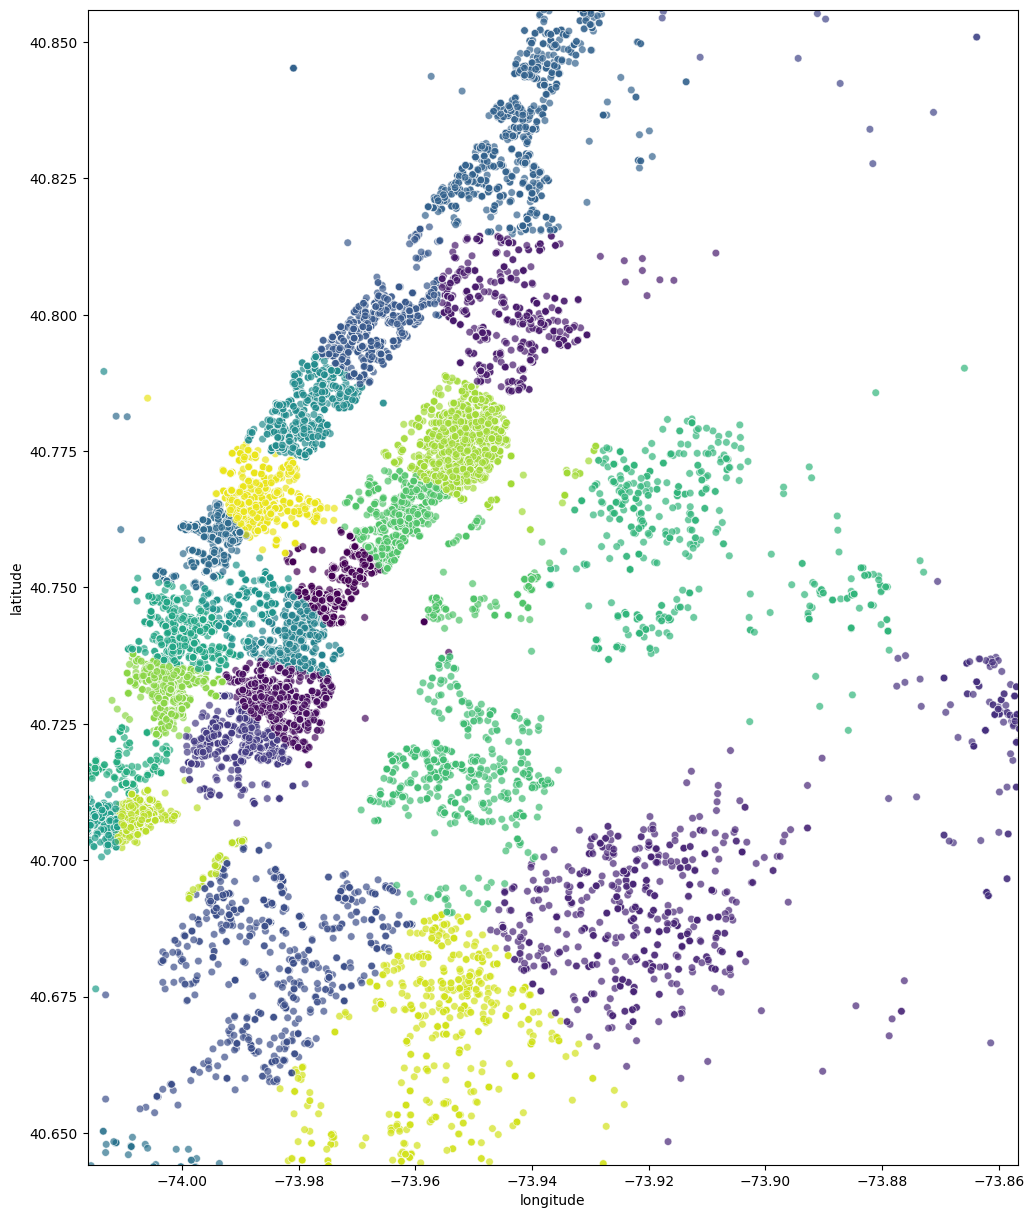

In [195]:
x = X_train[:, 0]  #longitude
y = X_train[:, 1]  #latitude

plt.figure(figsize=(12, 15))
plt.scatter(x, y, c=clusters_train, s=30, alpha=0.7,
            edgecolors="white", linewidth=0.5)

xlo, xhi = np.quantile(x, [0.01, 0.99])
ylo, yhi = np.quantile(y, [0.01, 0.99])
plt.xlim(xlo, xhi)
plt.ylim(ylo, yhi)

plt.xlabel("longitude")
plt.ylabel("latitude")
plt.show()

In [197]:
coefs, lasso_metrics = check_coefs(df_train,y_train, df_test, y_test, clusters_train, clusters_test, lasso_metrics, 'lasso_with_kmeans')
print(coefs.sort_values(by='lasso_coef',ascending=False))

                     lasso_coef
bathrooms          14361.481838
bedrooms            3908.155675
interest_level       831.270890
Doorman              559.597289
LaundryinUnit        434.013243
cluster              222.230324
Elevator             210.272417
FitnessCenter        193.754495
LaundryInBuilding    191.279575
LaundryinBuilding    186.922895
HighSpeedInternet    172.798401
Dishwasher           143.495848
HardwoodFloors       124.081555
Terrace              122.768837
RoofDeck             107.295149
DiningRoom           101.906465
NewConstruction       93.323118
NoFee                 80.660706
DogsAllowed           74.086953
Pre-War               40.459540
OutdoorSpace          38.375790
SwimmingPool          12.749725
CatsAllowed           10.703812
Balcony                0.000000


In [199]:
clustering_metrics = calculate_metrcis(model_kmeans,X_train, clusters_train, clustering_metrics, 'my_kmeans_train')
clustering_metrics = calculate_metrcis(model_kmeans,X_test, clusters_test, clustering_metrics, 'my_kmeans_test')

In [200]:
sk_model = KMeans(30,init='random')
clusters_sk_train = sk_model.fit_predict(X_train)
clusters_sk_test = sk_model.predict(X_test)
clustering_metrics = calculate_metrcis(sk_model, X_train, clusters_sk_train, clustering_metrics, 'sk_kmeans_train')
clustering_metrics = calculate_metrcis(sk_model, X_test, clusters_sk_test, clustering_metrics, 'sk_kmeans_test')

clustering_metrics

,name_model,distortion,silhouette_score
0,my_kmeans_train,10.760593,0.413585
1,my_kmeans_test,10.760593,0.395279
2,sk_kmeans_train,10.756627,0.417784
3,sk_kmeans_test,10.756627,0.391384


### 4. DBSCAN algorithm

Теперь поговорим про DBSCAN. 

Данный алгоритм, также, как и KMeans, строится на расстояниях между точек, но при этом DBScan в большинстве случаях лучше. \
\
Алгоритм DBScana следующий:
- Поиск соседей от выбранной точки на расстоянии __eps__
- Если точка имеет возле себя __n_samples__ точек, включая саму себя, точка будет считаться ___ключевой___
- Расширение кластера, то есть мы смотрим другие точки и даем одну из каст: ключевая, граничная и мусорная

DBScan умеет кластеризовывать разные формы (привет kmeans) \
Еще яркое отличие от kmeans служит то, что необязательно выбирать количество кластеров, оно подбирается само алгоритмом, отталкиваясь от гиперпараметров \
Нельзя не упомянуть, что данный алгоритм хорошо справляется с выбросами, в отличие от kmeans

В общем 3:0 в пользу DBScana

In [201]:
class MyDBSCAN:
    def __init__(self, eps=0.5, min_samples=5):
        self.eps = float(eps)
        self.min_samples = int(min_samples)
        self.labels_ = None

    def fit(self, X):
        X = np.asarray(X, dtype=float)
        n = X.shape[0]

        labels = np.full(n, -99, dtype=int)   # -99 значит не входит пока что ни в один кластер
        cluster_id = 0

        for i in range(n):
            if labels[i] != -99:
                continue

            # 1) найти соседей i в eps-радиусе
            neighbors = self._region_query(X, i)

            # мусор, если сеседей меньше min_samples
            if len(neighbors) < self.min_samples:
                labels[i] = -1 
                continue

            self._expand_cluster(X, labels, i, neighbors, cluster_id)
            cluster_id += 1

        self.labels_ = labels

        return self
    
    def fit_predict(self, X):
        self.fit(X)
        return self.labels_

    def _region_query(self, X, i):
        diff = X - X[i]
        # нейросеть предложила оптимизировать код
        # использование np.einsum позволяет быстрее высчитывать sum(diff^2)
        dist2 = np.einsum("ij,ij->i", diff, diff)
        return np.flatnonzero(dist2 <= self.eps * self.eps).tolist()

    def _expand_cluster(self, X, labels, i, neighbors, cluster_id):
        labels[i] = cluster_id

        queue = list(neighbors)
        in_queue = set(queue)
        q_ptr = 0

        while q_ptr < len(queue):
            p = queue[q_ptr]
            q_ptr += 1

            if labels[p] == -1:
                labels[p] = cluster_id

            if labels[p] != -99:
                continue

            labels[p] = cluster_id
            p_neighbors = self._region_query(X, p)

            if len(p_neighbors) >= self.min_samples:
                for pn in p_neighbors:
                    if pn not in in_queue:
                        in_queue.add(pn)
                        queue.append(pn)


In [202]:
model_dbscan = MyDBSCAN(eps=0.0001)
clusters_train = model_dbscan.fit_predict(X_train)
model_dbscan_test = MyDBSCAN(eps=0.0001)
clusters_test = model_dbscan_test.fit_predict(X_test)

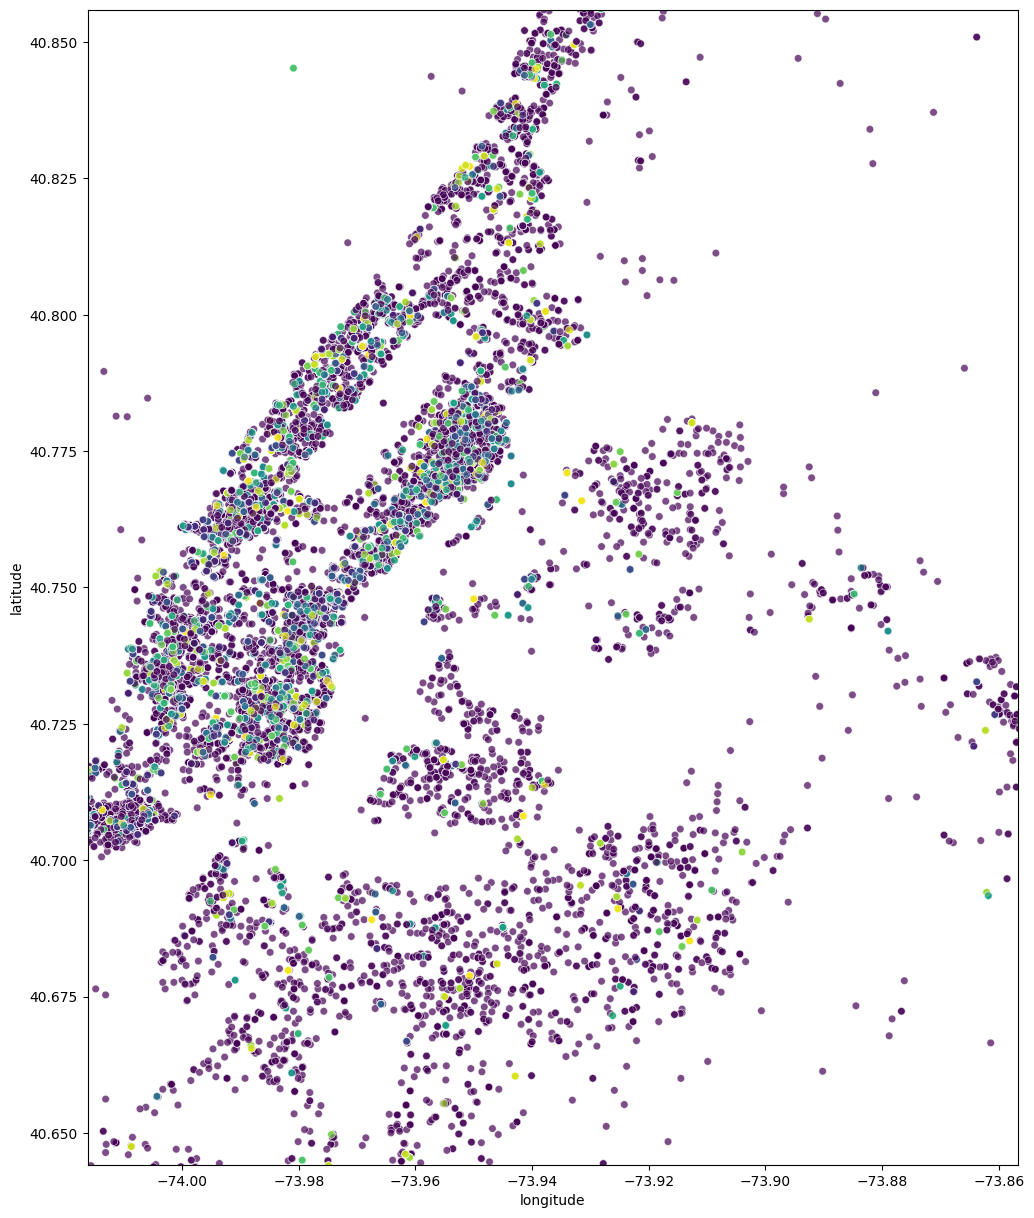

In [203]:
x = X_train[:, 0]  #longitude
y = X_train[:, 1]  #latitude

plt.figure(figsize=(12, 15))
plt.scatter(x, y, c=clusters_train, s=30, alpha=0.7,
            edgecolors="white", linewidth=0.5)

xlo, xhi = np.quantile(x, [0.01, 0.99])
ylo, yhi = np.quantile(y, [0.01, 0.99])
plt.xlim(xlo, xhi)
plt.ylim(ylo, yhi)

plt.xlabel("longitude")
plt.ylabel("latitude")
plt.show()

In [204]:
coefs, lasso_metrics = check_coefs(df_train,y_train, df_test, y_test, clusters_train, clusters_test,lasso_metrics,'lasso_with_dbscam')
print(coefs.sort_values(by='lasso_coef',ascending=False))

                     lasso_coef
bathrooms          14448.998747
bedrooms            3844.126729
interest_level       830.350270
Doorman              572.653508
LaundryinUnit        421.334200
cluster              255.666961
Elevator             206.343982
FitnessCenter        206.270320
HighSpeedInternet    187.144543
LaundryinBuilding    186.119603
LaundryInBuilding    165.235150
Dishwasher           147.159528
HardwoodFloors       129.514537
Terrace              127.281876
RoofDeck             100.067090
DiningRoom            97.831008
NewConstruction       84.847140
NoFee                 83.907528
DogsAllowed           66.809093
OutdoorSpace          44.908234
Pre-War               43.997246
SwimmingPool          24.673989
CatsAllowed           11.989248
Balcony                0.000000


In [ ]:
clustering_metrics = calculate_metrcis(model_dbscan,X_train, clusters_train, clustering_metrics, 'my_dbscan_train')
clustering_metrics = calculate_metrcis(model_dbscan_test, X_test, clusters_test, clustering_metrics, 'my_dbscan_test')

In [206]:
model_dbscan_sk_train = DBSCAN(0.0001, min_samples=5)
clusters_sk_train = model_dbscan_sk_train.fit_predict(X_train)

model_dbscan_sk_test = DBSCAN(0.0001,min_samples=5)
clusters_sk_test = model_dbscan_sk_test.fit_predict(X_test)

In [ ]:
clustering_metrics = calculate_metrcis(model_dbscan_sk_train,X_train, clusters_sk_train, clustering_metrics, 'sk_dbscan_train')
clustering_metrics = calculate_metrcis(model_dbscan_sk_test, X_test, clusters_sk_test, clustering_metrics, 'sk_dbscan_test')

In [208]:
clustering_metrics

,name_model,distortion,silhouette_score
0,my_kmeans_train,10.760593,0.413585
1,my_kmeans_test,10.760593,0.395279
2,sk_kmeans_train,10.756627,0.417784
3,sk_kmeans_test,10.756627,0.391384
4,my_dbscan_train,NaN,0.415869
5,my_dbscan_test,NaN,-0.095743
6,sk_dbscan_train,NaN,0.415869
7,sk_dbscan_test,NaN,-0.095743


### 5. AgglomerativeClustering algorithm

In [ ]:
connectivity = kneighbors_graph(
    X_train,
    n_neighbors=10,
    mode='connectivity',
    include_self=False
)

model_agg = AgglomerativeClustering(
    n_clusters=30,
    linkage='ward',
    connectivity=connectivity
)

clusters_train = model_agg.fit_predict(X_train)

# центроиды
centroids = np.vstack([
    X_train[clusters_train == c].mean(axis=0)
    for c in range(30)
])

clusters_test = pairwise_distances_argmin(X_test, centroids)

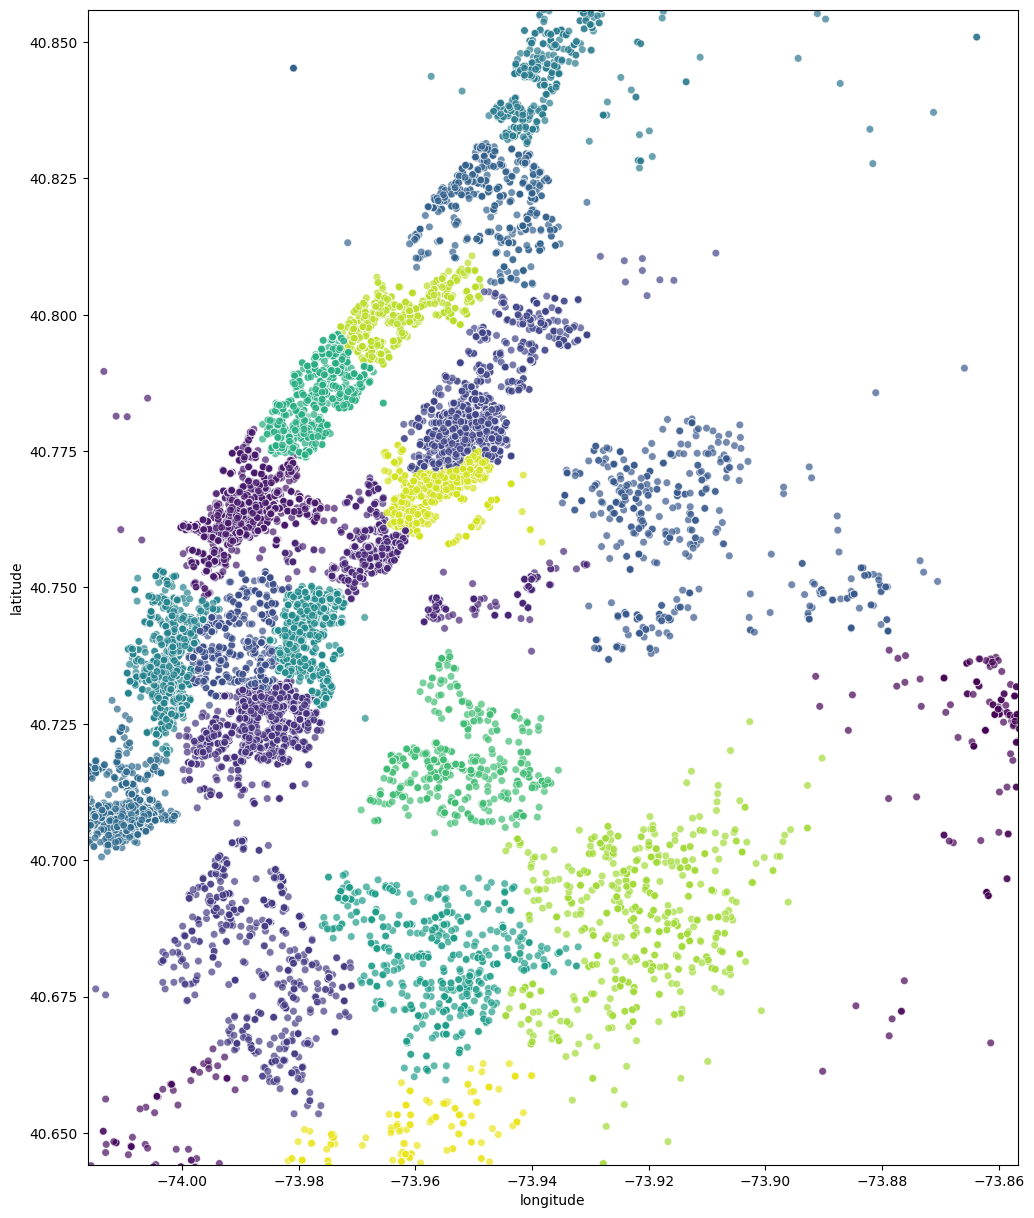

In [210]:
x = X_train[:, 0]  #longitude
y = X_train[:, 1]  #latitude

plt.figure(figsize=(12, 15))
plt.scatter(x, y, c=clusters_train, s=30, alpha=0.7,
            edgecolors="white", linewidth=0.5)

xlo, xhi = np.quantile(x, [0.01, 0.99])
ylo, yhi = np.quantile(y, [0.01, 0.99])
plt.xlim(xlo, xhi)
plt.ylim(ylo, yhi)

plt.xlabel("longitude")
plt.ylabel("latitude")
plt.show()

In [211]:
coefs, lasso_metrics = check_coefs(df_train,y_train, df_test, y_test, clusters_train, clusters_test, lasso_metrics, 'lasso_with_agglomerative')
print(coefs.sort_values(by='lasso_coef',ascending=False))

                     lasso_coef
bathrooms          14491.228906
bedrooms            3831.812499
interest_level       844.556623
Doorman              561.260023
LaundryinUnit        431.062241
Elevator             207.977537
FitnessCenter        201.486726
HighSpeedInternet    184.419137
LaundryinBuilding    183.569217
LaundryInBuilding    178.940337
Dishwasher           146.729443
Terrace              124.064065
HardwoodFloors       120.400593
RoofDeck             113.512564
DiningRoom           100.278048
cluster               95.044604
NewConstruction       94.547630
NoFee                 81.562265
DogsAllowed           61.928202
OutdoorSpace          46.635493
Pre-War               39.982406
SwimmingPool          23.961110
CatsAllowed            2.587741
Balcony                0.000000


In [ ]:
clustering_metrics = calculate_metrcis(model_agg, X_train, clusters_train, clustering_metrics, 'my_aglomeraive_train')
clustering_metrics = calculate_metrcis(model_agg, X_test, clusters_test, clustering_metrics, 'my_aglomeraive_test')

### 6. Gaussian Mixture algorithm.

In [213]:
model_gmm = GaussianMixture(
    n_components=30,
    covariance_type='full',
    random_state=42
)

clusters_train = model_gmm.fit_predict(X_train)
clusters_test = model_gmm.predict(X_test)


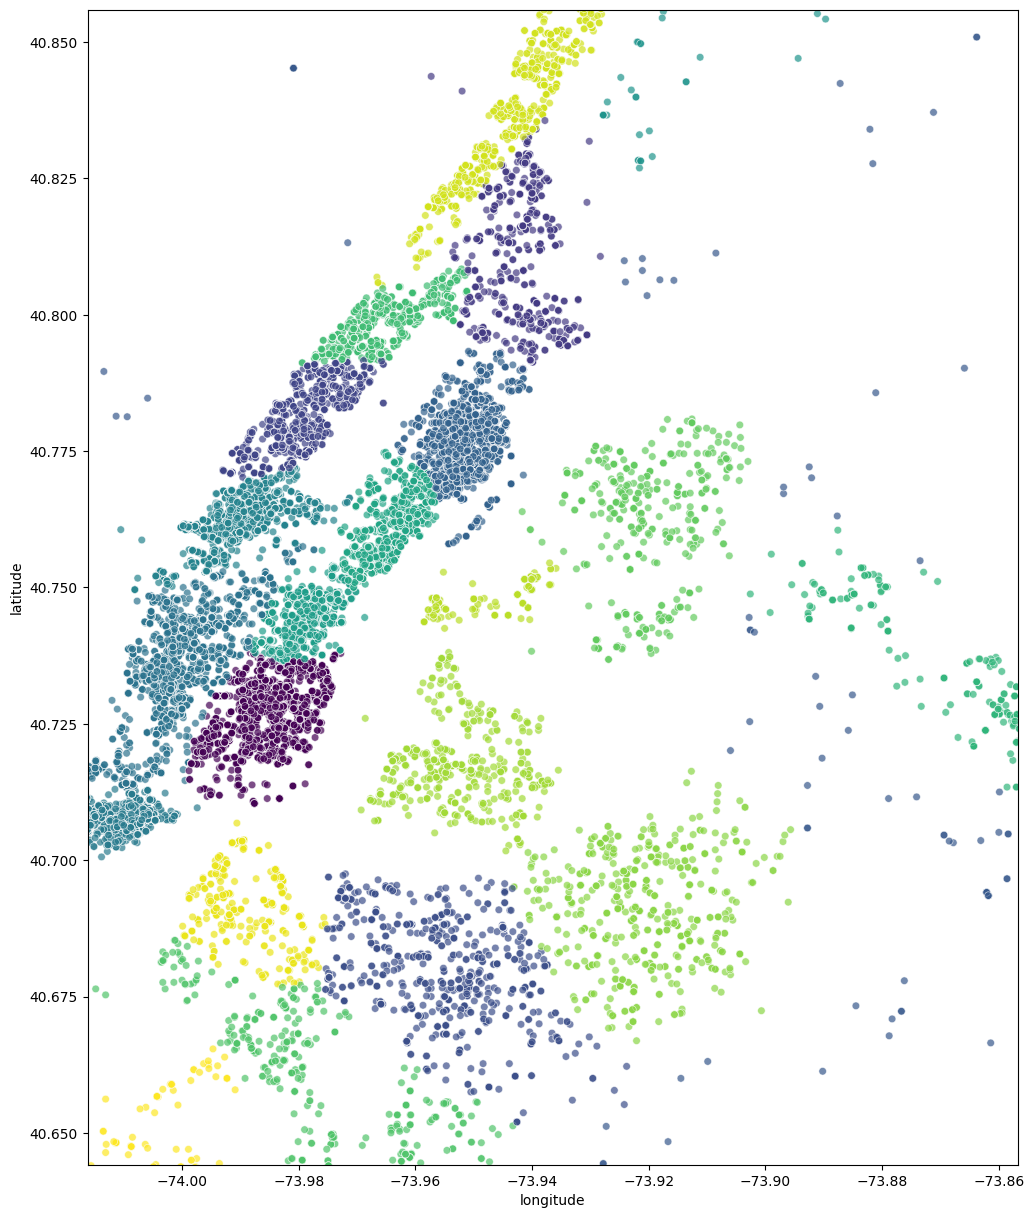

In [214]:
x = X_train[:, 0]  #longitude
y = X_train[:, 1]  #latitude

plt.figure(figsize=(12, 15))
plt.scatter(x, y, c=clusters_train, s=30, alpha=0.7,
            edgecolors="white", linewidth=0.5)

xlo, xhi = np.quantile(x, [0.01, 0.99])
ylo, yhi = np.quantile(y, [0.01, 0.99])
plt.xlim(xlo, xhi)
plt.ylim(ylo, yhi)

plt.xlabel("longitude")
plt.ylabel("latitude")
plt.show()

In [215]:
coefs, lasso_metrics = check_coefs(df_train,y_train, df_test, y_test, clusters_train, clusters_test,lasso_metrics,'lasso_with_mixture')
print(coefs.sort_values(by='lasso_coef',ascending=False))

                     lasso_coef
bathrooms          14270.067513
bedrooms            3924.934223
cluster              915.470135
interest_level       829.347649
Doorman              567.532143
LaundryinUnit        409.490998
Elevator             222.746139
FitnessCenter        208.815442
LaundryInBuilding    196.725402
LaundryinBuilding    176.785209
HardwoodFloors       166.964014
HighSpeedInternet    151.330414
Dishwasher           123.996706
DiningRoom           113.841009
Terrace              112.658545
RoofDeck              97.517881
DogsAllowed           57.908708
NoFee                 55.861900
OutdoorSpace          46.407305
Pre-War               36.500835
NewConstruction       32.493886
SwimmingPool          16.016297
CatsAllowed            0.000000
Balcony                0.000000


In [ ]:
clustering_metrics = calculate_metrcis(model_gmm, X_train, clusters_train, clustering_metrics, 'my_mixture_train')
clustering_metrics = calculate_metrcis(model_gmm, X_test, clusters_test, clustering_metrics, 'my_mixture_test')

### 7. Conclusion

In [217]:
clustering_metrics

,name_model,distortion,silhouette_score
0,my_kmeans_train,10.760593,0.413585
1,my_kmeans_test,10.760593,0.395279
2,sk_kmeans_train,10.756627,0.417784
3,sk_kmeans_test,10.756627,0.391384
4,my_dbscan_train,NaN,0.415869
5,my_dbscan_test,NaN,-0.095743
6,sk_dbscan_train,NaN,0.415869
7,sk_dbscan_test,NaN,-0.095743
8,my_aglomeraive_train,NaN,0.429197
9,my_aglomeraive_test,NaN,0.443876


По результатам видно, что моя реализация `K-Means` практически совпадает со `sklearn KMeans`, что подтверждает корректность алгоритма. \
`DBSCAN` показал плохое качество на тестовых данных, так как silhouette score стал отрицательным. \
Лучшие результаты по silhouette score на test дали `Agglomerative Clustering` и `Gaussian Mixture`, значит для данного датасета они лучше отражают внутреннюю структуру данных. 

Интересно, что лучший silhouette score не обязательно означает лучший результат в downstream-задаче. Хотя `Agglomerative Clustering` и `Gaussian Mixture` показали более высокие значения silhouette score, это ещё не гарантирует, что именно их кластерные метки окажутся наиболее полезными как дополнительные признаки для регрессии. Поэтому далее имеет смысл сравнить методы не только по внутренним метрикам кластеризации, но и по тому, насколько они улучшают качество итоговой модели предсказания цены.

In [218]:
lasso_metrics

,name_model,mae,rmse,r2
0,lasso_with_kmeans_train,688.415509,995.394289,0.605515
1,lasso_with_kmeans_test,684.863572,989.701873,0.612511
2,lasso_with_dbscam_train,685.198030,995.100200,0.605748
3,lasso_with_dbscam_test,677.332754,994.179813,0.608997
4,lasso_with_agglomerative_train,686.811602,997.549322,0.603805
5,lasso_with_agglomerative_test,682.998006,992.337634,0.610444
6,lasso_with_mixture_train,664.436225,972.117371,0.623749
7,lasso_with_mixture_test,663.855307,968.180440,0.629180


#### Вывод по использованию кластерных меток в регрессии

После добавления меток кластеров как дополнительного признака в модель `Lasso` оказалось, что разные методы кластеризации влияют на качество регрессии по-разному.

Лучшие результаты показала модель с метками, полученными из `Gaussian Mixture`:
- `MAE` на test: **663.86**
- `RMSE` на test: **968.18**
- `R²` на test: **0.629**

Это означает, что в данной задаче именно кластеры, найденные методом `Gaussian Mixture`, оказались наиболее полезными для предсказания стоимости недвижимости.

`K-Means` и `Agglomerative Clustering` также дали хорошие результаты, но немного уступили `Gaussian Mixture`.  
`DBSCAN` показал более слабое качество по RMSE и R², хотя по MAE оказался близок к другим методам.

Таким образом, можно сделать вывод, что:
- кластерные метки действительно могут быть полезны как инструмент **feature engineering**,
- лучший silhouette score не обязательно означает лучший результат в downstream-задаче,
- в данной постановке наиболее полезными для регрессии оказались метки, полученные с помощью `Gaussian Mixture`.

### 8. Try all these algorithms with different sets of features and compare the results with the complexity, speed and accuracy of these methods

In [ ]:
metrics = pd.DataFrame()

def check_metrics(model,X_train, y_train, X_test, y_test, lasso_metrics, name):
    basic_features = ['bathrooms','bedrooms','interest_level']

    X_train_three = X_train[basic_features]
    X_test_three = X_test[basic_features]

    start = time.time()

    model.fit(X_train_three)
    
    if 'dbscan' in name:
        labels_train = model.fit_predict(X_train_three)
        labels_test = model.fit_predict(X_test_three)

    elif 'agglomerative' in name:
        labels_train = model.fit_predict(X_train_three)
        labels_test = model.fit_predict(X_test_three)


    elif ('kmeans' or 'gmm') in name:
        labels_train = model.predict(X_train_three)
        labels_test = model.predict(X_test_three)

    X_train = X_train.copy()
    X_test = X_test.copy()

    X_train['cluster'] = labels_train
    X_test['cluster'] = labels_test
    
    scaler = MinMaxScaler()
    X_scaled_train = scaler.fit_transform(X_train)
    X_scaled_test = scaler.transform(X_test)

    lasso = Lasso(random_state=42)
    lasso.fit(X_scaled_train,y_train)
    
    y_predict_train = lasso.predict(X_scaled_train)
    y_predict_test = lasso.predict(X_scaled_test)

    end = time.time()
    
    row = pd.DataFrame(
        {
            "name_model" : [f'{name}_train'],
            "mae": [mean_absolute_error(y_train,y_predict_train)],
            "rmse": [root_mean_squared_error(y_train,y_predict_train)],
            'r2' : [r2_score(y_train, y_predict_train)],
            'time' : [end-start]
        }
    )

    lasso_metrics = pd.concat([lasso_metrics, row], axis=0, ignore_index=True)

    row = pd.DataFrame(
        {
            "name_model" : [f'{name}_test'],
            "mae": [mean_absolute_error(y_test,y_predict_test)],
            "rmse": [root_mean_squared_error(y_test,y_predict_test)],
            'r2' : [r2_score(y_test, y_predict_test)],
            'time' : [end-start]
        }
    )

    return pd.DataFrame(abs(lasso.coef_), index=X_train.columns, columns=['lasso_coef']), pd.concat([lasso_metrics, row], axis=0, ignore_index=True)


In [220]:
model = KMeans(n_clusters=30,random_state=42)

coefs, metrics = check_metrics(model, df_train, y_train, df_test, y_test, metrics, 'kmeans')

print(coefs.sort_values(by='lasso_coef',ascending=False))

                     lasso_coef
bathrooms          13380.440521
bedrooms            3445.565781
interest_level      1040.026569
cluster              839.217909
Doorman              572.205460
LaundryinUnit        415.208442
Elevator             197.608452
FitnessCenter        193.615982
LaundryinBuilding    181.668734
LaundryInBuilding    174.444039
HighSpeedInternet    168.948630
Dishwasher           156.521157
Terrace              119.129405
RoofDeck             107.885542
HardwoodFloors       105.211109
DiningRoom           103.318530
NewConstruction       95.543792
NoFee                 89.407402
DogsAllowed           69.489672
Pre-War               35.437431
OutdoorSpace          33.844210
SwimmingPool          30.420195
CatsAllowed            5.068698
Balcony                0.000000


In [221]:
model = DBSCAN(min_samples=5, eps=0.001)

coefs, metrics = check_metrics(model, df_train, y_train, df_test, y_test, metrics, 'dbscan')

print(coefs.sort_values(by='lasso_coef',ascending=False))

                     lasso_coef
bathrooms          13509.668466
bedrooms            3257.922149
cluster             1272.810363
interest_level       990.844002
Doorman              574.301103
LaundryinUnit        421.577210
FitnessCenter        204.115605
Elevator             202.689847
LaundryinBuilding    187.107561
LaundryInBuilding    177.640848
HighSpeedInternet    170.594259
Dishwasher           156.216250
Terrace              118.494935
HardwoodFloors       110.369353
RoofDeck             105.225627
DiningRoom            93.397711
NoFee                 90.231742
NewConstruction       86.371247
DogsAllowed           83.215557
OutdoorSpace          40.644947
Pre-War               33.762997
SwimmingPool          24.754708
CatsAllowed           11.653753
Balcony                0.000000


In [222]:
model = AgglomerativeClustering(n_clusters=30)

coefs, metrics = check_metrics(model, df_train, y_train, df_test, y_test, metrics, 'agglomerative')

print(coefs.sort_values(by='lasso_coef',ascending=False))

                     lasso_coef
bathrooms          14440.715989
bedrooms            3806.582603
interest_level       820.924755
Doorman              564.097869
LaundryinUnit        431.026163
Elevator             209.723958
FitnessCenter        203.238180
LaundryinBuilding    185.474084
HighSpeedInternet    180.596039
LaundryInBuilding    180.277679
Dishwasher           148.594971
Terrace              124.222124
HardwoodFloors       118.541399
RoofDeck             109.847986
DiningRoom           101.233027
NewConstruction       90.615901
NoFee                 84.190209
DogsAllowed           64.418690
cluster               55.949634
OutdoorSpace          44.998285
Pre-War               41.675165
SwimmingPool          28.501302
CatsAllowed            4.530411
Balcony                0.000000


In [223]:
metrics

,name_model,mae,rmse,r2,time
0,kmeans_train,678.585259,989.275677,0.610349,0.030590
1,kmeans_test,672.420735,979.512499,0.620449,0.030590
2,dbscan_train,679.829260,987.883849,0.611445,2.220918
3,dbscan_test,673.342029,986.234316,0.615222,2.220918
4,agglomerative_train,687.138584,997.925405,0.603506,29.285271
5,agglomerative_test,682.099033,991.824237,0.610847,29.285271


Как мы видим по коэффициентам, наша новая фича имеет большой вес и входит в топ 5 признаков по lasso_coef на моделях KMeans и DBSCAN